# 한국어 → 영어 Seq2Seq Attention 번역 모델

**jungyeul/korean-parallel-corpora** 데이터를 사용한 한영 번역 실험

## Step 0. 환경 설정

In [ ]:
# !mkdir -p ~/work/s2s_translation

In [1]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install konlpy
!pip install nltk
!pip install Korpora

# MeCab 및 한국어 사전 설치
import subprocess, os, sys

def install_mecab():
    """MeCab + 한국어 사전 설치 시도"""
    try:
        # 1. mecab 엔진 설치
        subprocess.run('sudo apt-get install -y mecab libmecab-dev mecab-ipadic-utf8 automake', shell=True, check=True)
        subprocess.run(f'{sys.executable} -m pip install mecab-python3', shell=True, check=True)
        
        # 2. mecab-ko-dic 한국어 사전 설치
        if not os.path.exists('/usr/local/lib/mecab/dic/mecab-ko-dic'):
            cmds = [
                'cd /tmp && curl -LO https://bitbucket.org/eunjeon/mecab-ko-dic/downloads/mecab-ko-dic-2.1.1-20180720.tar.gz',
                'cd /tmp && tar -xzf mecab-ko-dic-2.1.1-20180720.tar.gz',
                'cd /tmp/mecab-ko-dic-2.1.1-20180720 && ./autogen.sh && ./configure && make && sudo make install',
            ]
            for cmd in cmds:
                subprocess.run(cmd, shell=True, check=True)
        
        # 3. 테스트
        from konlpy.tag import Mecab
        m = Mecab()
        m.morphs('테스트')
        print('✅ MeCab 설치 성공!')
        return True
    except Exception as e:
        print(f'⚠️ MeCab 설치 실패: {e}')
        return False

MECAB_AVAILABLE = install_mecab()

if not MECAB_AVAILABLE:
    print('→ 대체 토크나이저(Okt)를 사용합니다.')

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease0m
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
125 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 125 not upgraded.
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  autoconf autotools-dev libmecab2 m4 mecab-ipadic mecab-jumandic
  mecab-jumandic-utf8 mecab-utils
Suggested packages:
  autoconf-archive gnu-standards autoconf-doc libtool gettext m4-doc
The following NEW packages will be insta

debconf: delaying package configuration, since apt-utils is not installed


Fetched 24.7 MB in 4s (5810 kB/s)
Selecting previously unselected package m4.
(Reading database ... 52770 files and directories currently installed.)
Preparing to unpack .../00-m4_1.4.19-4build1_amd64.deb ...
Unpacking m4 (1.4.19-4build1) ...
Selecting previously unselected package autoconf.
Preparing to unpack .../01-autoconf_2.71-3_all.deb ...
Unpacking autoconf (2.71-3) ...
Selecting previously unselected package autotools-dev.
Preparing to unpack .../02-autotools-dev_20220109.1_all.deb ...
Unpacking autotools-dev (20220109.1) ...
Selecting previously unselected package automake.
Preparing to unpack .../03-automake_1%3a1.16.5-1.3ubuntu1_all.deb ...
Unpacking automake (1:1.16.5-1.3ubuntu1) ...
Selecting previously unselected package libmecab2:amd64.
Preparing to unpack .../04-libmecab2_0.996-14ubuntu4_amd64.deb ...
Unpacking libmecab2:amd64 (0.996-14ubuntu4) ...
Selecting previously unselected package libmecab-dev.
Preparing to unpack .../05-libmecab-dev_0.996-14ubuntu4_amd64.deb ...

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 47.4M  100 47.4M    0     0  9651k      0  0:00:05  0:00:05 --:--:-- 14.5M


Looking in current directory for macros.


configure.ac:2: warning: AM_INIT_AUTOMAKE: two- and three-arguments forms are deprecated.
./lib/autoconf/general.m4:2434: AC_DIAGNOSE is expanded from...
aclocal.m4:139: AM_INIT_AUTOMAKE is expanded from...
configure.ac:2: the top level
configure.ac:56: warning: AC_OUTPUT should be used without arguments.
configure.ac:56: You should run autoupdate.
configure.ac:2: warning: AM_INIT_AUTOMAKE: two- and three-arguments forms are deprecated.  For more info, see:
configure.ac:2: https://www.gnu.org/software/automake/manual/automake.html#Modernize-AM_005fINIT_005fAUTOMAKE-invocation


checking for a BSD-compatible install... /usr/bin/install -c
checking whether build environment is sane... yes
checking for a race-free mkdir -p... /usr/bin/mkdir -p
checking for gawk... no
checking for mawk... mawk
checking whether make sets $(MAKE)... yes
checking whether make supports nested variables... yes
checking for mecab-config... /usr/bin/mecab-config
checking that generated files are newer than configure... 

/tmp/mecab-ko-dic-2.1.1-20180720/missing: Unknown `--is-lightweight' option
Try `/tmp/mecab-ko-dic-2.1.1-20180720/missing --help' for more information
configure: WARNING: 'missing' script is too old or missing


done
configure: creating ./config.status
config.status: creating Makefile
/usr/lib/mecab/mecab-dict-index -d . -o . -f UTF-8 -t UTF-8
reading ./unk.def ... 13
emitting double-array: 100% |###########################################| 
reading ./ETM.csv ... 133
reading ./Person-actor.csv ... 99230
reading ./ETN.csv ... 14
reading ./NP.csv ... 342
reading ./Foreign.csv ... 11690
reading ./Group.csv ... 3176
reading ./XPN.csv ... 83
reading ./Place-address.csv ... 19301
reading ./XSV.csv ... 23
reading ./MAG.csv ... 14242
reading ./VV.csv ... 7331
reading ./Person.csv ... 196459
reading ./Wikipedia.csv ... 36762
reading ./MAJ.csv ... 240
reading ./Place-station.csv ... 1145
reading ./EF.csv ... 1820
reading ./NorthKorea.csv ... 3
reading ./XR.csv ... 3637
reading ./VCN.csv ... 7
reading ./Place.csv ... 30303
reading ./NNB.csv ... 140
reading ./VCP.csv ... 9
reading ./NNBC.csv ... 677
reading ./NNP.csv ... 2371
reading ./IC.csv ... 1305
reading ./XSN.csv ... 124
reading ./Symbol.csv ... 16


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [3]:
import os
import re
import urllib.request
import tarfile
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from collections import Counter
from tqdm import tqdm
import random
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as nltk_meteor_score

nltk.download('wordnet')
nltk.download('omw-1.4')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.7.1+cu118
Device: cuda


[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jovyan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [9]:
!sudo apt-get install -y default-jdk
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/default-java'

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  adwaita-icon-theme at-spi2-common at-spi2-core bsdutils ca-certificates-java
  dbus dbus-bin dbus-daemon dbus-session-bus-common dbus-system-bus-common
  dbus-user-session dconf-gsettings-backend dconf-service default-jdk-headless
  default-jre default-jre-headless dmsetup fonts-dejavu-core
  fonts-dejavu-extra fonts-dejavu-mono gir1.2-girepository-2.0 gir1.2-glib-2.0
  gsettings-desktop-schemas gtk-update-icon-cache hicolor-icon-theme
  humanity-icon-theme java-common libargon2-1 libatk-bridge2.0-0t64
  libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0t64 libatspi2.0-0t64
  libblkid1 libcolord2 libcryptsetup12 libdconf1 libdevmapper1.02.1 libepoxy0
  libfdisk1 libgif7 libgirepository-1.0-1 libglib2.0-0t64 libgtk-3-0t64
  libgtk-3-bin libgtk-3-common libice-dev libjson-c5 libkmod2 libmount1
  libnspr4 libnss-systemd libnss3 libpam

## Step 1. 데이터 다운로드

jungyeul/korean-parallel-corpora에서 `korean-english-park.train.tar.gz`를 다운로드받아 한영 병렬 데이터를 확보합니다.

In [4]:
# Korpora 패키지를 이용하여 한영 병렬 데이터 다운로드
from Korpora import Korpora

Korpora.fetch("korean_parallel_koen_news")
corpus = Korpora.load("korean_parallel_koen_news")

print(f"Train 데이터 수: {len(corpus.train)}")
print(f"Dev 데이터 수: {len(corpus.dev)}")
print(f"Test 데이터 수: {len(corpus.test)}")
print(f"\n예시 (한국어): {corpus.train[0].text}")
print(f"예시 (영어): {corpus.train[0].pair}")

[Korpora] Corpus `korean_parallel` is already installed at /home/jovyan/Korpora/korean_parallel/korean-english-park.train.tar.gz
decompress /home/jovyan/Korpora/korean_parallel/korean-english-park.train.tar.gz
[Korpora] Corpus `korean_parallel` is already installed at /home/jovyan/Korpora/korean_parallel/korean-english-park.dev.tar.gz
decompress /home/jovyan/Korpora/korean_parallel/korean-english-park.dev.tar.gz
[Korpora] Corpus `korean_parallel` is already installed at /home/jovyan/Korpora/korean_parallel/korean-english-park.test.tar.gz
decompress /home/jovyan/Korpora/korean_parallel/korean-english-park.test.tar.gz

    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : KakaoBrain
    Repository : https://github.com/jungyeul/korean-parallel-corpora
    References :
     

In [5]:
# Korpora corpus 객체에서 한국어, 영어 문장 추출
kor_lines = corpus.train.get_all_texts()  # 한국어 문장
eng_lines = corpus.train.get_all_pairs()  # 영어 문장

print(f"한국어 문장 수: {len(kor_lines)}")
print(f"영어 문장 수: {len(eng_lines)}")
print(f"\n예시 (한국어): {kor_lines[0]}")
print(f"예시 (영어): {eng_lines[0]}")

한국어 문장 수: 94123
영어 문장 수: 94123

예시 (한국어): 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
예시 (영어): Much of personal computing is about "can you top this?"


## Step 2. 데이터 정제

- `set` 데이터형을 활용해 중복 제거 → `cleaned_corpus`에 저장
- 한글 정규식을 추가한 `preprocessing()` 함수 재정의
- 영문 타겟에 `<start>`, `<end>` 토큰 추가, `split()` 함수로 토큰화
- 한글 토큰화는 KoNLPy의 Mecab 클래스 사용
- 토큰 길이 40 이하인 데이터만 선별 → `eng_corpus`, `kor_corpus`

In [6]:
# 한글을 지원하는 전처리 함수 재정의
def preprocess_sentence_kor(sentence):
    """한국어 문장 전처리"""
    sentence = sentence.strip()
    # 한글, 숫자, 공백, 기본 문장부호만 유지
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    # 한글(가-힣), 숫자, 기본 문장부호, 공백만 유지
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,\s]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

def preprocess_sentence_eng(sentence):
    """영어 문장 전처리: <start>와 <end> 토큰 추가"""
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    # 타겟 언어(영문)에 <start>와 <end> 토큰 추가
    sentence = "<start> " + sentence + " <end>"
    return sentence

print("전처리 함수 정의 완료!")
print(f"한국어 예시: '{preprocess_sentence_kor(kor_lines[0])}'")
print(f"영어 예시: '{preprocess_sentence_eng(eng_lines[0])}'")

전처리 함수 정의 완료!
한국어 예시: '개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?'
영어 예시: '<start> much of personal computing is about can you top this ? <end>'


In [7]:
# 중복 제거: set 데이터형 활용 (병렬 쌍이 흐트러지지 않게 주의!)
# (kor, eng) 튜플을 set에 넣어 중복 제거
corpus_pairs = list(zip(kor_lines, eng_lines))
print(f"원본 데이터 수: {len(corpus_pairs)}")

# set으로 중복 제거
cleaned_corpus = list(set(corpus_pairs))
print(f"중복 제거 후 데이터 수: {len(cleaned_corpus)}")

원본 데이터 수: 94123
중복 제거 후 데이터 수: 78968


In [10]:
# 토크나이저 초기화 (MeCab 우선, 실패 시 Okt 사용)
if MECAB_AVAILABLE:
    from konlpy.tag import Mecab
    mecab = Mecab()
    def kor_morphs(text):
        return kor_morphs(text)
    print('한국어 토크나이저: Mecab')
else:
    from konlpy.tag import Okt
    okt = Okt()
    def kor_morphs(text):
        return okt.morphs(text)
    print('한국어 토크나이저: Okt (Mecab 대체)')

# 토큰 길이 40 이하인 데이터만 선별하여 eng_corpus, kor_corpus 구축
MAX_TOKEN_LEN = 40

kor_corpus = []
eng_corpus = []

for kor_sent, eng_sent in tqdm(cleaned_corpus, desc="필터링 중"):
    kor_processed = preprocess_sentence_kor(kor_sent)
    eng_processed = preprocess_sentence_eng(eng_sent)
    
    # 한국어: Mecab으로 토큰화하여 길이 체크
    kor_tokens = kor_morphs(kor_processed)
    # 영어: split()으로 토큰화하여 길이 체크
    eng_tokens = eng_processed.split()
    
    if len(kor_tokens) <= MAX_TOKEN_LEN and len(eng_tokens) <= MAX_TOKEN_LEN:
        kor_corpus.append(kor_processed)
        eng_corpus.append(eng_processed)

print(f"\n필터링 후 최종 데이터 수: {len(kor_corpus)}")
print(f"\n한국어 예시: {kor_corpus[:3]}")
print(f"영어 예시: {eng_corpus[:3]}")

한국어 토크나이저: Okt (Mecab 대체)


필터링 중: 100%|██████████| 78968/78968 [03:50<00:00, 342.14it/s]


필터링 후 최종 데이터 수: 65991

한국어 예시: ['더하멜의 대리인인 루스 번스타인은 더하멜이 지난해 첫 솔로앨범  더 더치스 The Dutchess 를 발표한 피기와 약혼식을 올렸다고 전했다 .', '이 배터리는 휴렛패커드 , 델 그리고 도시바에서 제조한 노트북 컴퓨터와 함께 전세계적으로 판매되었습니다 .', '그는 의원들에게 이란 문제를 외교적 방법 외 에 다른 방법으로 해결하고 싶어 하는 사람은 없다 며 어느 누구도 이란과 전쟁을 벌이고 싶어하지 않는다 라고 말했다 .']
영어 예시: ['<start> duhamel s publicist , ruth bernstein , said her client recently popped the question to the pop star , whose debut solo album is titled the dutchess . she did not release any other details . <end>', '<start> they were sold around the world for laptops made by hewlett packard , dell , and toshiba . <end>', '<start> no one wants to resolve the issue with iran in anything other than a diplomatic way , blair told lawmakers . no one is looking for confrontation with iran . <end>']


## Step 3. 데이터 토큰화

- 한국어: Mecab 형태소 분석기로 토큰화
- 영어: `split()` 함수로 토큰화
- 단어 사전 구축 (vocab_size 최소 10,000 이상)
- 난이도에 비해 데이터가 많지 않아 훈련/검증 데이터를 따로 나누지 않음

In [11]:
# 토큰화 함수 정의
def tokenize_kor(sentences):
    """한국어 문장을 Mecab으로 토큰화"""
    tokenized = []
    for sent in tqdm(sentences, desc="한국어 토큰화"):
        tokens = kor_morphs(sent)
        tokenized.append(tokens)
    return tokenized

def tokenize_eng(sentences):
    """영어 문장을 split()으로 토큰화"""
    tokenized = []
    for sent in sentences:
        tokens = sent.split()
        tokenized.append(tokens)
    return tokenized

# 토큰화 수행
kor_tokenized = tokenize_kor(kor_corpus)
eng_tokenized = tokenize_eng(eng_corpus)

print(f"\n한국어 토큰화 예시: {kor_tokenized[0]}")
print(f"영어 토큰화 예시: {eng_tokenized[0]}")

한국어 토큰화: 100%|██████████| 65991/65991 [03:01<00:00, 363.20it/s]



한국어 토큰화 예시: ['더', '하멜', '의', '대리인', '인', '루스', '번스타인', '은', '더', '하멜', '이', '지난해', '첫', '솔로', '앨범', '더', '더치', '스', 'The', 'Dutchess', '를', '발표', '한', '피기', '와', '약혼', '식', '을', '올렸다고', '전', '했다', '.']
영어 토큰화 예시: ['<start>', 'duhamel', 's', 'publicist', ',', 'ruth', 'bernstein', ',', 'said', 'her', 'client', 'recently', 'popped', 'the', 'question', 'to', 'the', 'pop', 'star', ',', 'whose', 'debut', 'solo', 'album', 'is', 'titled', 'the', 'dutchess', '.', 'she', 'did', 'not', 'release', 'any', 'other', 'details', '.', '<end>']


In [12]:
# 단어 사전(Vocabulary) 구축 클래스
class Tokenizer:
    def __init__(self, name=""):
        self.name = name
        self.word2idx = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
        self.idx2word = {0: "<pad>", 1: "<start>", 2: "<end>", 3: "<unk>"}
        self.word_count = Counter()
        self.n_words = 4  # 특수 토큰 수
    
    def build_vocab(self, tokenized_sentences, min_freq=1):
        """토큰화된 문장 리스트로부터 사전 구축"""
        for tokens in tokenized_sentences:
            for token in tokens:
                self.word_count[token] += 1
        
        for word, count in self.word_count.items():
            if count >= min_freq and word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1
        
        print(f"[{self.name}] 사전 크기: {self.n_words}")
    
    def encode(self, tokens):
        """토큰 리스트를 인덱스 리스트로 변환"""
        return [self.word2idx.get(token, self.word2idx["<unk>"]) for token in tokens]
    
    def decode(self, indices):
        """인덱스 리스트를 토큰 리스트로 변환"""
        tokens = []
        for idx in indices:
            word = self.idx2word.get(idx, "<unk>")
            tokens.append(word)
            if word == "<end>":
                break
        return tokens
    
    def __len__(self):
        return self.n_words

# 사전 구축
kor_tokenizer = Tokenizer(name="Korean")
kor_tokenizer.build_vocab(kor_tokenized, min_freq=1)

eng_tokenizer = Tokenizer(name="English")
eng_tokenizer.build_vocab(eng_tokenized, min_freq=1)

print(f"\n한국어 사전 크기: {len(kor_tokenizer)} (최소 10,000 이상 권장)")
print(f"영어 사전 크기: {len(eng_tokenizer)} (최소 10,000 이상 권장)")

[Korean] 사전 크기: 59958
[English] 사전 크기: 40937

한국어 사전 크기: 59958 (최소 10,000 이상 권장)
영어 사전 크기: 40937 (최소 10,000 이상 권장)


In [13]:
# 인코딩 확인
sample_kor = kor_tokenized[0]
sample_eng = eng_tokenized[0]

print(f"한국어 토큰: {sample_kor}")
print(f"한국어 인코딩: {kor_tokenizer.encode(sample_kor)}")
print(f"\n영어 토큰: {sample_eng}")
print(f"영어 인코딩: {eng_tokenizer.encode(sample_eng)}")

한국어 토큰: ['더', '하멜', '의', '대리인', '인', '루스', '번스타인', '은', '더', '하멜', '이', '지난해', '첫', '솔로', '앨범', '더', '더치', '스', 'The', 'Dutchess', '를', '발표', '한', '피기', '와', '약혼', '식', '을', '올렸다고', '전', '했다', '.']
한국어 인코딩: [4, 5, 6, 7, 8, 9, 10, 11, 4, 5, 12, 13, 14, 15, 16, 4, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

영어 토큰: ['<start>', 'duhamel', 's', 'publicist', ',', 'ruth', 'bernstein', ',', 'said', 'her', 'client', 'recently', 'popped', 'the', 'question', 'to', 'the', 'pop', 'star', ',', 'whose', 'debut', 'solo', 'album', 'is', 'titled', 'the', 'dutchess', '.', 'she', 'did', 'not', 'release', 'any', 'other', 'details', '.', '<end>']
영어 인코딩: [1, 4, 5, 6, 7, 8, 9, 7, 10, 11, 12, 13, 14, 15, 16, 17, 15, 18, 19, 7, 20, 21, 22, 23, 24, 25, 15, 26, 27, 28, 29, 30, 31, 32, 33, 34, 27, 2]


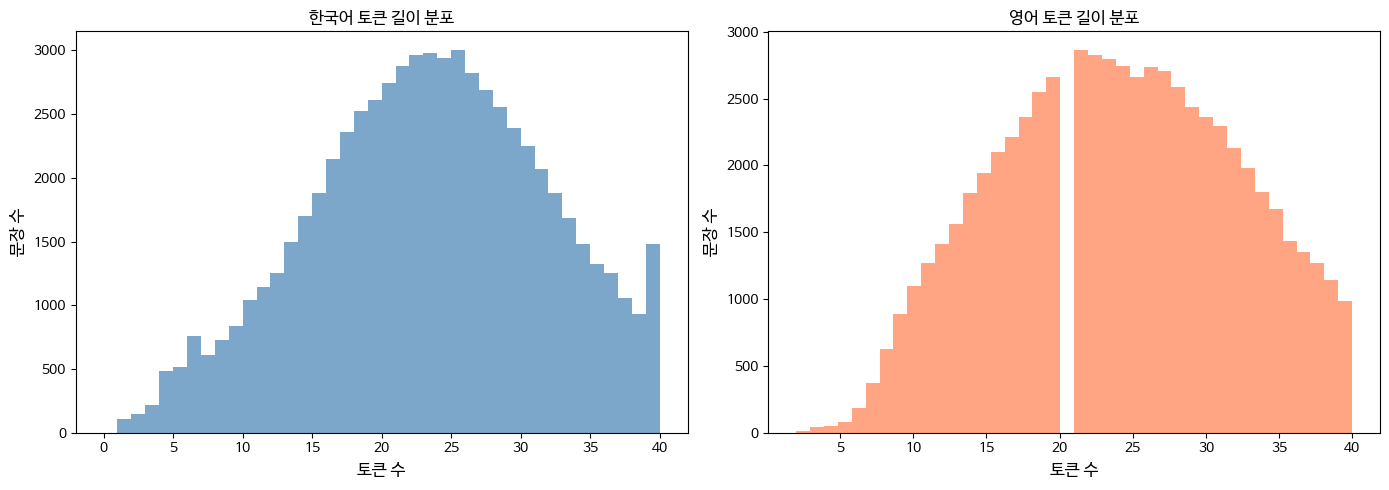

한국어 평균 토큰 수: 22.9, 최대: 40
영어 평균 토큰 수: 24.0, 최대: 40


In [14]:
# 토큰 길이 분포 시각화
kor_lens = [len(t) for t in kor_tokenized]
eng_lens = [len(t) for t in eng_tokenized]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(kor_lens, bins=40, color='steelblue', alpha=0.7)
axes[0].set_title('한국어 토큰 길이 분포', fontproperties=fontprop)
axes[0].set_xlabel('토큰 수', fontproperties=fontprop)
axes[0].set_ylabel('문장 수', fontproperties=fontprop)

axes[1].hist(eng_lens, bins=40, color='coral', alpha=0.7)
axes[1].set_title('영어 토큰 길이 분포', fontproperties=fontprop)
axes[1].set_xlabel('토큰 수', fontproperties=fontprop)
axes[1].set_ylabel('문장 수', fontproperties=fontprop)

plt.tight_layout()
plt.show()

print(f"한국어 평균 토큰 수: {np.mean(kor_lens):.1f}, 최대: {max(kor_lens)}")
print(f"영어 평균 토큰 수: {np.mean(eng_lens):.1f}, 최대: {max(eng_lens)}")

In [15]:
# Dataset 클래스 정의
class TranslationDataset(Dataset):
    def __init__(self, kor_tokenized, eng_tokenized, kor_tokenizer, eng_tokenizer, max_len):
        self.kor_tokenized = kor_tokenized
        self.eng_tokenized = eng_tokenized
        self.kor_tokenizer = kor_tokenizer
        self.eng_tokenizer = eng_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.start_id = 1
        self.end_id = 2

    def __len__(self):
        return len(self.kor_tokenized)

    def __getitem__(self, idx):
        # 소스(한국어) 인코딩
        src_ids = self.kor_tokenizer.encode(self.kor_tokenized[idx])
        src_ids = src_ids[:self.max_len]

        # 타겟(영어)은 이미 <start>와 <end>가 포함되어 있음
        trg_tokens = self.eng_tokenized[idx]
        trg_ids = self.eng_tokenizer.encode(trg_tokens)
        
        # trg_input: <start> ... (디코더 입력)
        # trg_label: ... <end> (디코더 정답)
        trg_input = trg_ids[:self.max_len]  # <start>부터 시작
        trg_label = trg_ids[1:self.max_len + 1]  # <start> 제외, <end> 포함

        # 패딩
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [16]:
# 데이터 로더 생성 (훈련/검증 분리하지 않음 - 과제 조건)
MAX_LEN = 40
BATCH_SIZE = 64

train_dataset = TranslationDataset(
    kor_tokenized, eng_tokenized, 
    kor_tokenizer, eng_tokenizer, 
    max_len=MAX_LEN
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"전체 데이터셋 크기: {len(train_dataset)}")
print(f"배치 수: {len(train_loader)}")

# 배치 크기 확인
for src, trg_input, trg_label in train_loader:
    print(f"src shape: {src.shape}, trg_input shape: {trg_input.shape}, trg_label shape: {trg_label.shape}")
    break

전체 데이터셋 크기: 65991
배치 수: 1032
src shape: torch.Size([64, 40]), trg_input shape: torch.Size([64, 40]), trg_label shape: torch.Size([64, 40])


## Step 4. 모델 설계

Attention 기반 Seq2Seq 모델 (Bahdanau Attention)
- Embedding Size와 Hidden Size는 실험을 통해 적당한 값 설정

In [17]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs_perm = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.W1(encoder_outputs_perm) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        return nn.functional.softmax(attention, dim=1)

In [18]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, n_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim, num_layers=n_layers, dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

In [19]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, n_layers=1, dropout=0.3):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim, num_layers=n_layers, dropout=dropout if n_layers > 1 else 0)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        encoder_outputs_perm = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs_perm)
        context = context.permute(1, 0, 2)
        output, hidden = self.rnn(embedded, hidden)
        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))
        return prediction, hidden, a.squeeze(1)

In [20]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=40, start_id=1, end_id=2):
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features
        outputs = []
        attentions = []
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            input = torch.full((batch_size,), start_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1
                finished |= (top1 == end_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)
        return outputs, attentions

In [21]:
# 하이퍼파라미터 설정 (실험을 통해 적당한 값 선택)
INPUT_DIM = len(kor_tokenizer)
OUTPUT_DIM = len(eng_tokenizer)
EMB_DIM = 256       # Embedding Size
HID_DIM = 512       # Hidden Size
N_LAYERS = 1
DROPOUT = 0.3

print(f"입력 사전 크기 (한국어): {INPUT_DIM}")
print(f"출력 사전 크기 (영어): {OUTPUT_DIM}")
print(f"Embedding Size: {EMB_DIM}")
print(f"Hidden Size: {HID_DIM}")

입력 사전 크기 (한국어): 59958
출력 사전 크기 (영어): 40937
Embedding Size: 256
Hidden Size: 512


In [22]:
encoder = Encoder(INPUT_DIM, EMB_DIM, HID_DIM, N_LAYERS, DROPOUT).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM, attention, N_LAYERS, DROPOUT).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

# 모델 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"총 파라미터 수: {total_params:,}")
print(f"학습 가능 파라미터 수: {trainable_params:,}")
print(f"\n{model}")

총 파라미터 수: 70,680,809
학습 가능 파라미터 수: 70,680,809

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(59958, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(40937, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=40937, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


## Step 5. 훈련하기

In [24]:
PAD_ID = 0

optimizer = optim.AdamW(
    model.parameters(), 
    lr=1e-3,
    weight_decay=1e-2,
    betas=(0.9, 0.999)
)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

# 학습률 스케줄러
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("옵티마이저 및 손실함수 설정 완료!")

옵티마이저 및 손실함수 설정 완료!


In [25]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs, _ = model(src, trg_input)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("train_step 함수 정의 완료!")

train_step 함수 정의 완료!


In [26]:
def eval_step(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            outputs, _ = model(src, trg_input)
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)
            total_loss += loss.item()

    return total_loss / len(data_loader)

print("eval_step 함수 정의 완료!")

eval_step 함수 정의 완료!


In [27]:
%%time

EPOCHS = 20
train_losses = []
best_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    eval_loss = eval_step(model, train_loader, criterion)  # 전체 데이터로 eval
    
    train_losses.append(train_loss)
    scheduler.step(train_loss)
    
    # 최적 모델 저장
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save(model.state_dict(), 'best_model.pt')
    
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Eval Loss: {eval_loss:.4f}')

Epoch 1: 100%|██████████| 1032/1032 [08:15<00:00,  2.08it/s, loss=4.51]


Epoch 1/20, Train Loss: 5.6658, Eval Loss: 4.4559


Epoch 2: 100%|██████████| 1032/1032 [08:14<00:00,  2.09it/s, loss=5.07]


Epoch 2/20, Train Loss: 4.5026, Eval Loss: 3.4842


Epoch 3: 100%|██████████| 1032/1032 [08:14<00:00,  2.09it/s, loss=3.58]


...

Epoch 18/20, Train Loss: 1.9644, Eval Loss: 1.3801


Epoch 19: 100%|██████████| 1032/1032 [08:15<00:00,  2.08it/s, loss=2.08]


Epoch 19/20, Train Loss: 1.9249, Eval Loss: 1.3452


Epoch 20: 100%|██████████| 1032/1032 [08:15<00:00,  2.08it/s, loss=1.86]


Epoch 20/20, Train Loss: 1.8842, Eval Loss: 1.3067
CPU times: user 3h 2min 59s, sys: 32min 24s, total: 3h 35min 23s
Wall time: 3h 35min 11s


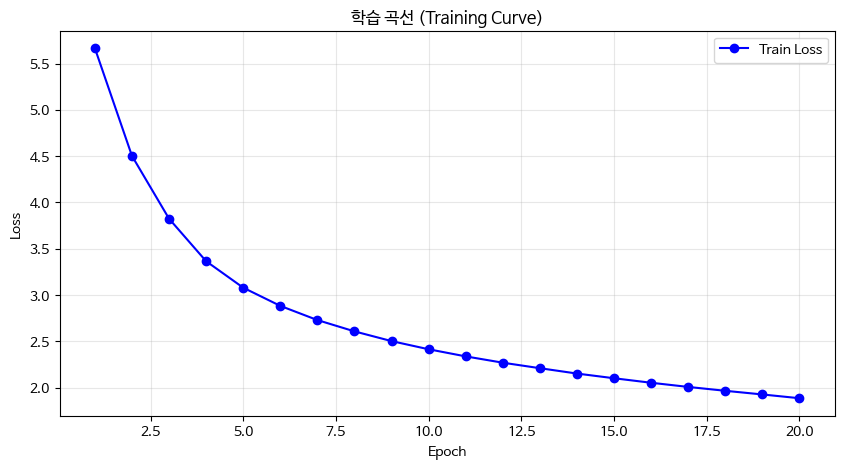

In [41]:
# 학습 곡선 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('학습 곡선 (Training Curve)', fontproperties=fontprop)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 6. 번역 및 Attention 시각화

In [28]:
def evaluate_sentence(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40):
    """한국어 문장을 입력으로 받아 영어 번역 결과를 반환"""
    model.eval()

    # 전처리 + Mecab 토큰화
    processed = preprocess_sentence_kor(sentence)
    kor_tokens = kor_morphs(processed)
    src_ids = kor_tokenizer.encode(kor_tokens)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    # 디코딩
    predicted_ids = outputs.argmax(2).squeeze(1).cpu().numpy()
    result = eng_tokenizer.decode(predicted_ids.tolist())

    return result, kor_tokens, attentions.squeeze(1).cpu().numpy()

In [29]:
def plot_attention(attention, src_tokens, predicted_tokens):
    """Attention Map 시각화"""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # attention 크기 조정
    attn = attention[:len(predicted_tokens), :len(src_tokens)]
    
    ax.matshow(attn, cmap='viridis')
    
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, fontproperties=fontprop, fontsize=12, rotation=90)
    
    ax.set_yticks(range(len(predicted_tokens)))
    ax.set_yticklabels(predicted_tokens, fontsize=12)
    
    ax.set_xlabel('한국어 입력', fontproperties=fontprop, fontsize=14)
    ax.set_ylabel('영어 출력', fontsize=14)
    
    plt.tight_layout()
    plt.show()

In [30]:
def translate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40, show_attention=True):
    """한국어 문장을 영어로 번역하고 Attention Map을 시각화"""
    result, src_tokens, attention = evaluate_sentence(
        sentence, model, kor_tokenizer, eng_tokenizer, max_len
    )

    # 결과 문자열 생성
    result_str = ' '.join(result)
    
    print(f'입력 (Korean): {sentence}')
    print(f'토큰화: {src_tokens}')
    print(f'번역 (English): {result_str}')
    print()

    if show_attention:
        plot_attention(attention, src_tokens, result)
    
    return result

In [31]:
# 최적 모델 로드
model.load_state_dict(torch.load('best_model.pt'))
print("최적 모델 로드 완료!")

최적 모델 로드 완료!


## 예문 번역 결과 ##

--- K1) 오바마는 대통령이다. ---
입력 (Korean): 오바마는 대통령이다.
토큰화: ['오바마', '는', '대통령', '이다', '.']
번역 (English): obama s president is on the first lady <end>



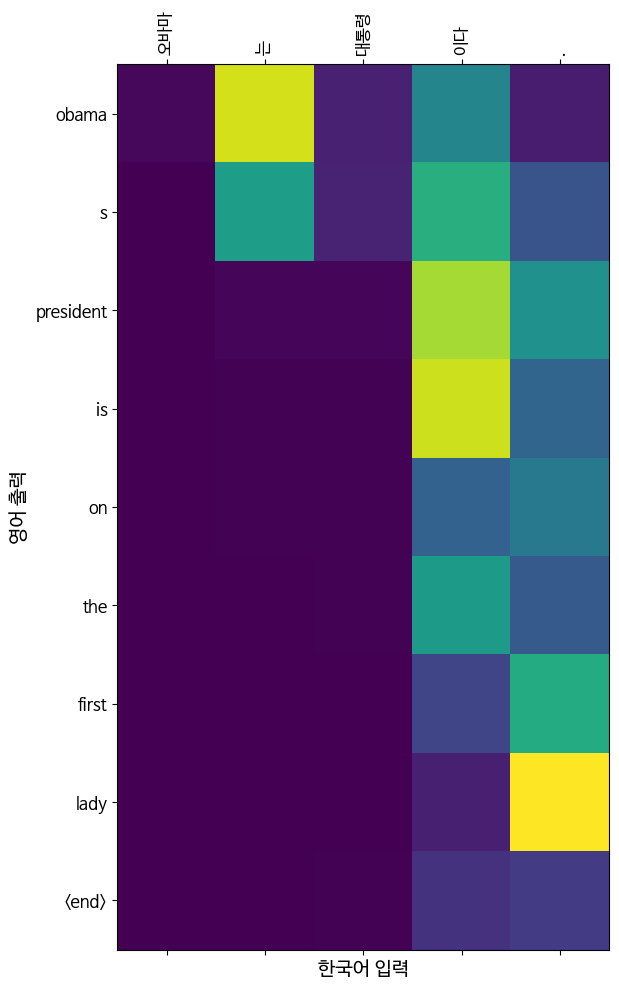


--- K2) 시민들은 도시 속에 산다. ---
입력 (Korean): 시민들은 도시 속에 산다.
토큰화: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
번역 (English): civil servants were gathered in cities . <end>



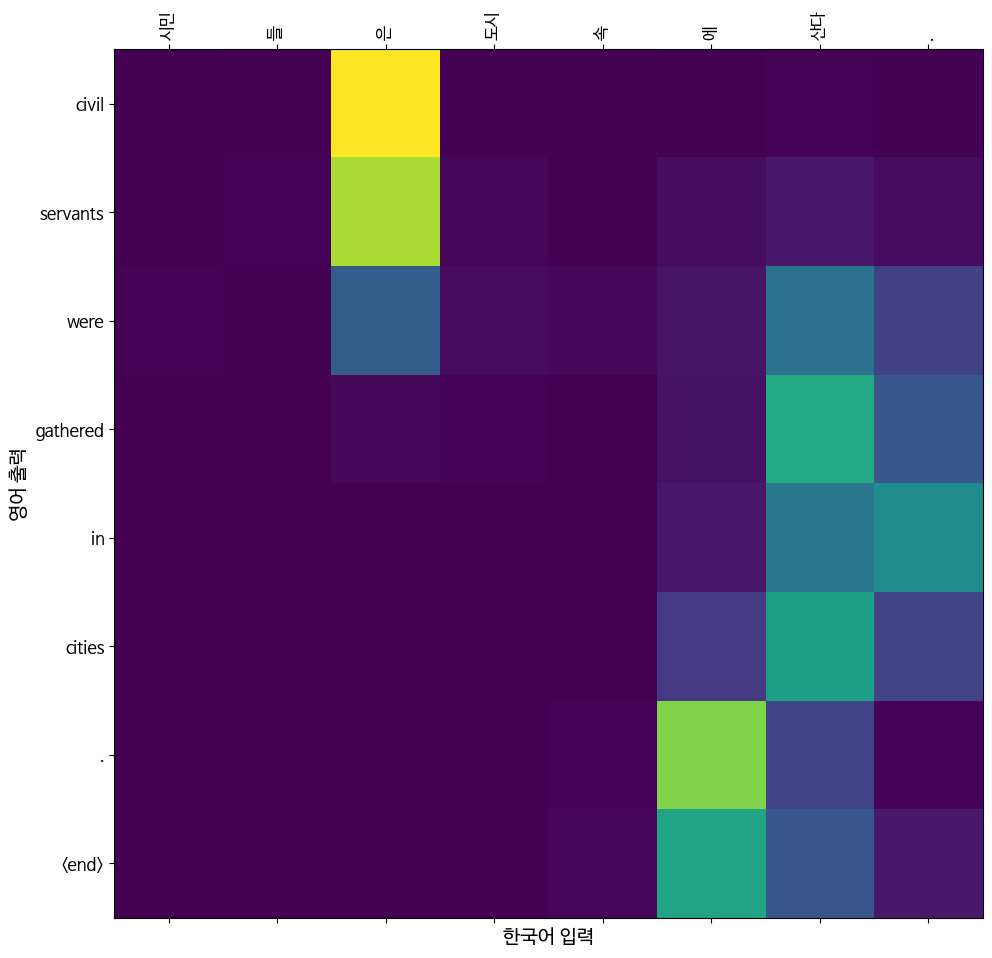


--- K3) 커피는 필요 없다. ---
입력 (Korean): 커피는 필요 없다.
토큰화: ['커피', '는', '필요', '없다', '.']
번역 (English): coffee is not coffee . <end>



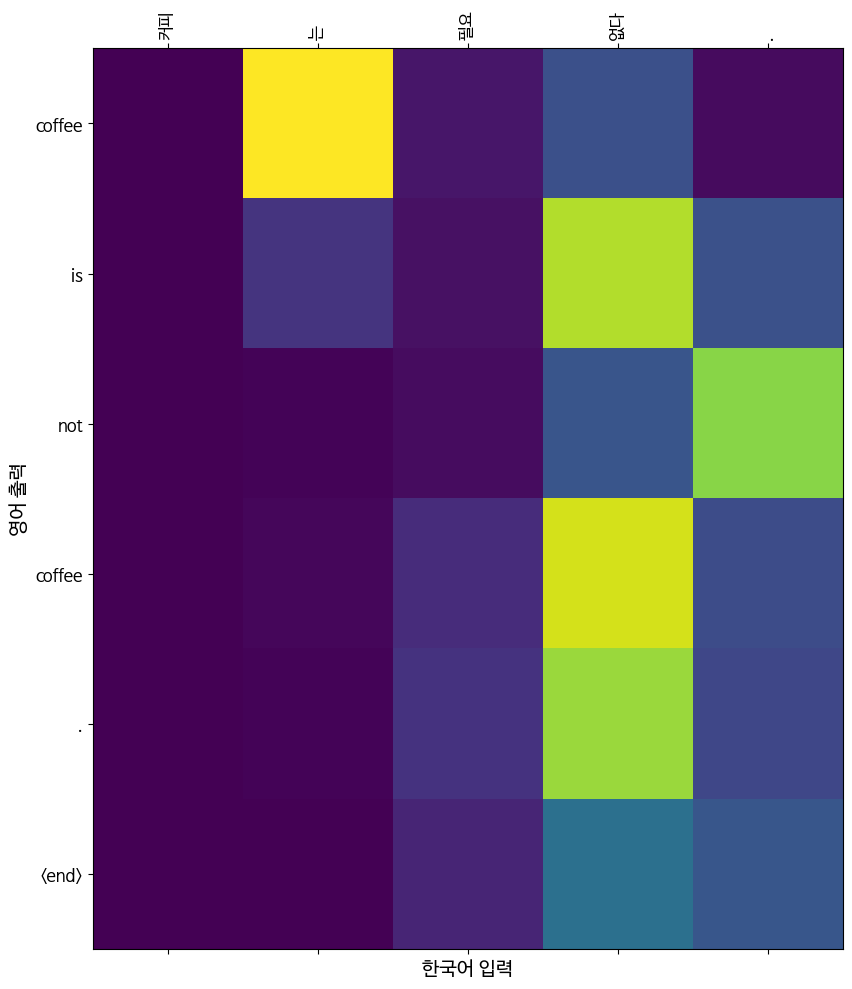


--- K4) 일곱 명의 사망자가 발생했다. ---
입력 (Korean): 일곱 명의 사망자가 발생했다.
토큰화: ['일곱', '명의', '사망자', '가', '발생', '했다', '.']
번역 (English): seven people were killed , the drama said . <end>



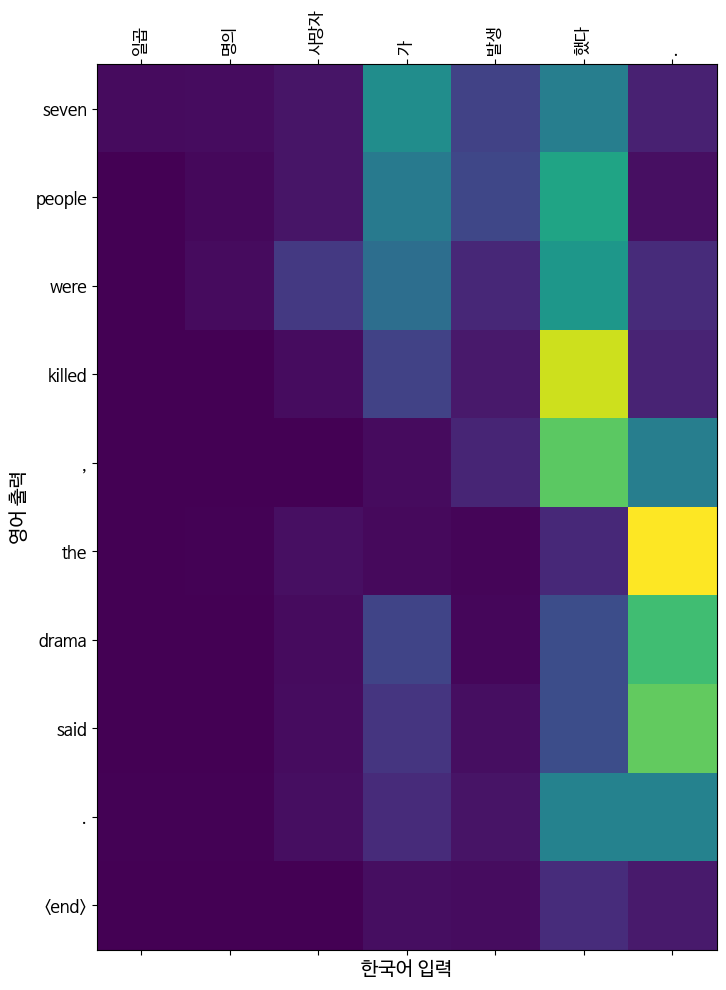

In [32]:
# 과제 예문 번역
print("="*60)
print("## 예문 번역 결과 ##")
print("="*60)

test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for i, sent in enumerate(test_sentences, 1):
    print(f"\n--- K{i}) {sent} ---")
    result = translate(sent, model, kor_tokenizer, eng_tokenizer, show_attention=True)

In [33]:
# 추가 번역 테스트
additional_tests = [
    "나는 학교에 간다.",
    "오늘 날씨가 좋다.",
    "그는 의사이다.",
    "우리는 친구이다.",
    "한국은 아름다운 나라이다."
]

print("="*60)
print("## 추가 번역 테스트 ##")
print("="*60)

for sent in additional_tests:
    translate(sent, model, kor_tokenizer, eng_tokenizer, show_attention=False)

## 추가 번역 테스트 ##
입력 (Korean): 나는 학교에 간다.
토큰화: ['나', '는', '학교', '에', '간다', '.']
번역 (English): i want to school . <end>

입력 (Korean): 오늘 날씨가 좋다.
토큰화: ['오늘', '날씨', '가', '좋다', '.']
번역 (English): today , weather forecast today . <end>

입력 (Korean): 그는 의사이다.
토큰화: ['그', '는', '의사', '이다', '.']
번역 (English): he is the doctor he s . <end>

입력 (Korean): 우리는 친구이다.
토큰화: ['우리', '는', '친구', '이다', '.']
번역 (English): we are all gonna be friends . <end>

입력 (Korean): 한국은 아름다운 나라이다.
토큰화: ['한국', '은', '아름다운', '나라', '이다', '.']
번역 (English): south korea is beautiful a lot of korean deep countries . <end>



## Step 7. 정량적 평가 (언어모델 성능 지표)

번역 모델의 성능을 다양한 정량적 지표로 평가합니다:
- **BLEU Score** (Bilingual Evaluation Understudy): n-gram 기반 정밀도 측정
  - BLEU-1, BLEU-2, BLEU-3, BLEU-4 및 Corpus BLEU
- **METEOR Score**: 동의어와 어간을 고려한 평가 지표
- **Perplexity**: 모델의 확률적 불확실성 측정
- **Token Accuracy**: 토큰 단위 정확도
- **Exact Match Rate**: 완전 일치율

In [34]:
def compute_bleu_scores(references, hypotheses):
    """BLEU-1, BLEU-2, BLEU-3, BLEU-4 및 Corpus BLEU 계산"""
    smooth = SmoothingFunction().method1
    
    bleu_1_scores = []
    bleu_2_scores = []
    bleu_3_scores = []
    bleu_4_scores = []
    
    for ref, hyp in zip(references, hypotheses):
        # ref는 [reference_tokens], hyp는 hypothesis_tokens
        bleu_1 = sentence_bleu([ref], hyp, weights=(1, 0, 0, 0), smoothing_function=smooth)
        bleu_2 = sentence_bleu([ref], hyp, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu_3 = sentence_bleu([ref], hyp, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu_4 = sentence_bleu([ref], hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
        
        bleu_1_scores.append(bleu_1)
        bleu_2_scores.append(bleu_2)
        bleu_3_scores.append(bleu_3)
        bleu_4_scores.append(bleu_4)
    
    # Corpus BLEU
    corpus_bleu_score = corpus_bleu(
        [[ref] for ref in references], hypotheses, 
        smoothing_function=smooth
    )
    
    return {
        'BLEU-1': np.mean(bleu_1_scores),
        'BLEU-2': np.mean(bleu_2_scores),
        'BLEU-3': np.mean(bleu_3_scores),
        'BLEU-4': np.mean(bleu_4_scores),
        'Corpus BLEU': corpus_bleu_score
    }


def compute_meteor(references, hypotheses):
    """METEOR Score 계산"""
    scores = []
    for ref, hyp in zip(references, hypotheses):
        # nltk meteor_score은 reference가 문자열, hypothesis가 문자열
        score = nltk_meteor_score([ref], hyp)
        scores.append(score)
    return np.mean(scores)


def compute_token_accuracy(references, hypotheses):
    """토큰 단위 정확도 계산"""
    correct = 0
    total = 0
    for ref, hyp in zip(references, hypotheses):
        min_len = min(len(ref), len(hyp))
        for i in range(min_len):
            if ref[i] == hyp[i]:
                correct += 1
        total += max(len(ref), len(hyp))
    return correct / total if total > 0 else 0


def compute_exact_match(references, hypotheses):
    """완전 일치율 계산"""
    matches = sum(1 for ref, hyp in zip(references, hypotheses) if ref == hyp)
    return matches / len(references) if references else 0


print("평가 함수 정의 완료!")

평가 함수 정의 완료!


In [35]:
def evaluate_model(model, kor_corpus, eng_corpus, kor_tokenizer, eng_tokenizer,
                   num_samples=1000, max_len=40):
    """모델 성능 종합 평가"""
    model.eval()
    
    # 샘플링
    indices = random.sample(range(len(kor_corpus)), min(num_samples, len(kor_corpus)))
    
    references = []  # 정답 토큰 리스트
    hypotheses = []  # 예측 토큰 리스트
    
    print(f"총 {len(indices)}개 문장 평가 중...")
    
    for idx in tqdm(indices, desc="평가 진행"):
        kor_sent = kor_corpus[idx]
        eng_sent = eng_corpus[idx]  # <start> ... <end> 형태
        
        # 정답: <start>와 <end> 제거
        ref_tokens = eng_sent.split()
        ref_tokens = [t for t in ref_tokens if t not in ['<start>', '<end>']]
        
        # 예측
        result, _, _ = evaluate_sentence(kor_sent, model, kor_tokenizer, eng_tokenizer, max_len)
        hyp_tokens = [t for t in result if t not in ['<start>', '<end>', '<pad>']]
        
        if len(ref_tokens) > 0 and len(hyp_tokens) > 0:
            references.append(ref_tokens)
            hypotheses.append(hyp_tokens)
    
    # BLEU Score 계산
    bleu_scores = compute_bleu_scores(references, hypotheses)
    
    # METEOR Score 계산
    meteor = compute_meteor(references, hypotheses)
    
    # Token Accuracy 계산
    token_acc = compute_token_accuracy(references, hypotheses)
    
    # Exact Match Rate 계산
    exact_match = compute_exact_match(references, hypotheses)
    
    return bleu_scores, meteor, token_acc, exact_match, references, hypotheses

print("종합 평가 함수 정의 완료!")

종합 평가 함수 정의 완료!


In [36]:
# Perplexity 계산
def compute_perplexity(model, data_loader, criterion):
    """Perplexity 계산 (Cross-Entropy Loss로부터)"""
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    with torch.no_grad():
        for src, trg_input, trg_label in tqdm(data_loader, desc="Perplexity 계산"):
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            outputs, _ = model(src, trg_input)
            outputs = outputs.reshape(-1, outputs.shape[-1])
            labels = trg_label.reshape(-1)

            # PAD 토큰을 제외한 유효 토큰 수
            non_pad = (labels != PAD_ID).sum().item()
            loss = criterion(outputs, labels)

            total_loss += loss.item() * non_pad
            total_tokens += non_pad

    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return perplexity

print("Perplexity 함수 정의 완료!")

Perplexity 함수 정의 완료!


In [37]:
# ============================================
# 종합 평가 실행
# ============================================

print("="*60)
print("번역 모델 정량적 성능 평가")
print("="*60)

# 1. BLEU, METEOR, Token Accuracy, Exact Match
bleu_scores, meteor, token_acc, exact_match, refs, hyps = evaluate_model(
    model, kor_corpus, eng_corpus, kor_tokenizer, eng_tokenizer,
    num_samples=1000
)

# 2. Perplexity
perplexity = compute_perplexity(model, train_loader, criterion)

print("\n" + "="*60)
print("         [정량적 평가 결과 요약]")
print("="*60)
print(f"  BLEU-1 Score:      {bleu_scores['BLEU-1']:.4f}")
print(f"  BLEU-2 Score:      {bleu_scores['BLEU-2']:.4f}")
print(f"  BLEU-3 Score:      {bleu_scores['BLEU-3']:.4f}")
print(f"  BLEU-4 Score:      {bleu_scores['BLEU-4']:.4f}")
print(f"  Corpus BLEU:       {bleu_scores['Corpus BLEU']:.4f}")
print(f"  METEOR Score:      {meteor:.4f}")
print(f"  Perplexity:        {perplexity:.2f}")
print(f"  Token Accuracy:    {token_acc:.4f} ({token_acc*100:.2f}%)")
print(f"  Exact Match Rate:  {exact_match:.4f} ({exact_match*100:.2f}%)")
print("="*60)

번역 모델 정량적 성능 평가
총 1000개 문장 평가 중...


Perplexity 계산: 100%|██████████| 1032/1032 [02:28<00:00,  6.93it/s]


         [정량적 평가 결과 요약]
  BLEU-1 Score:      0.4052
  BLEU-2 Score:      0.2609
  BLEU-3 Score:      0.1884
  BLEU-4 Score:      0.1398
  Corpus BLEU:       0.1653
  METEOR Score:      0.3709
  Perplexity:        3.70
  Token Accuracy:    0.1105 (11.05%)
  Exact Match Rate:  0.0100 (1.00%)


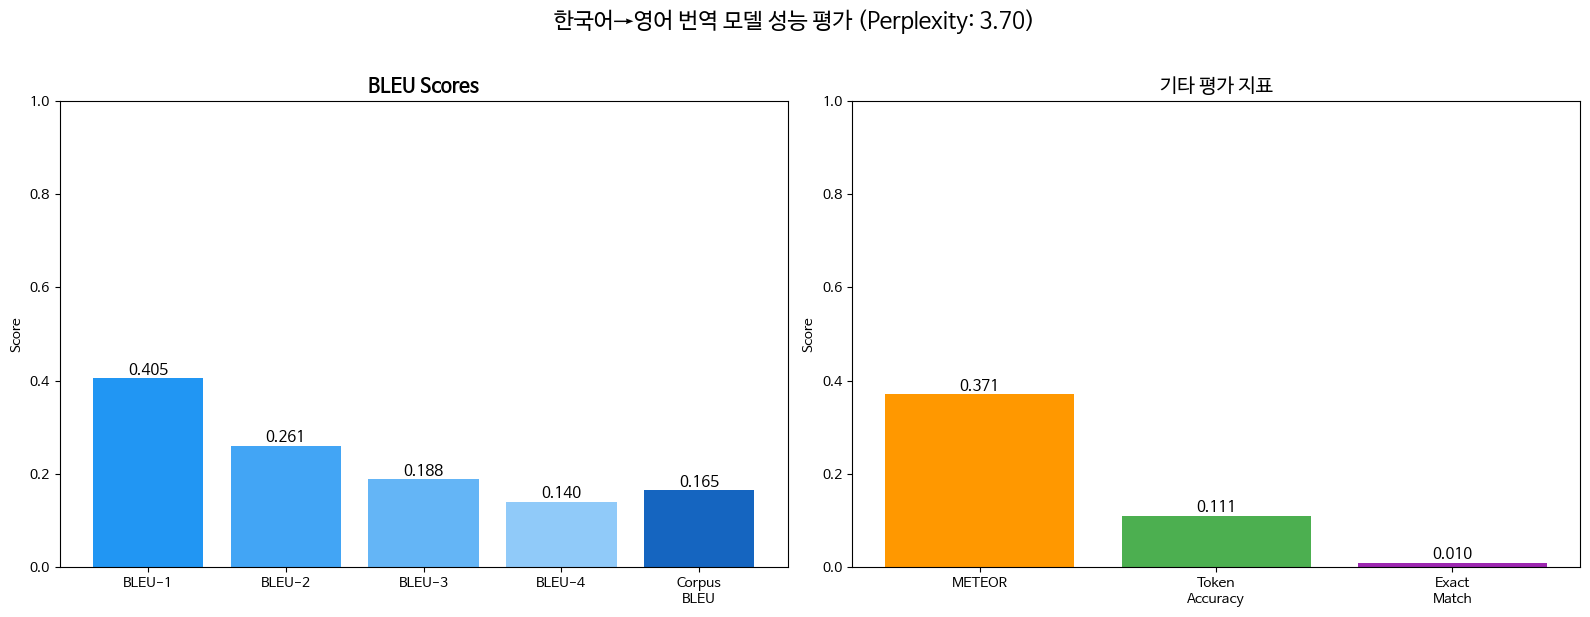

In [38]:
# 평가 지표 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BLEU Score 비교
bleu_names = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'Corpus\nBLEU']
bleu_values = [
    bleu_scores['BLEU-1'], bleu_scores['BLEU-2'], 
    bleu_scores['BLEU-3'], bleu_scores['BLEU-4'],
    bleu_scores['Corpus BLEU']
]
colors = ['#2196F3', '#42A5F5', '#64B5F6', '#90CAF9', '#1565C0']

bars = axes[0].bar(bleu_names, bleu_values, color=colors)
axes[0].set_title('BLEU Scores', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars, bleu_values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11)

# 기타 지표 비교
metric_names = ['METEOR', 'Token\nAccuracy', 'Exact\nMatch']
metric_values = [meteor, token_acc, exact_match]
colors2 = ['#FF9800', '#4CAF50', '#9C27B0']

bars2 = axes[1].bar(metric_names, metric_values, color=colors2)
axes[1].set_title('기타 평가 지표', fontproperties=fontprop, fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.0)
for bar, val in zip(bars2, metric_values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11)

plt.suptitle(f'한국어→영어 번역 모델 성능 평가 (Perplexity: {perplexity:.2f})', 
             fontproperties=fontprop, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [44]:
# 번역 품질 예시 (정답 vs 예측 비교)
print("="*60)
print("번역 품질 예시 (Reference vs Prediction)")
print("="*60)

sample_indices = random.sample(range(len(refs)), min(10, len(refs)))

for i, idx in enumerate(sample_indices):
    ref_str = ' '.join(refs[idx])
    hyp_str = ' '.join(hyps[idx])
    
    smooth = SmoothingFunction().method1
    sent_bleu = sentence_bleu([refs[idx]], hyps[idx], smoothing_function=smooth)
    
    print(f"\n[{i+1}]")
    print(f"  Reference:  {ref_str}")
    print(f"  Prediction: {hyp_str}")
    print(f"  BLEU-4:     {sent_bleu:.4f}")

번역 품질 예시 (Reference vs Prediction)

[1]
  Reference:  benedict greeted tens of thousands in jesus biblical hometown of nazareth today .
  Prediction: benedict greeted tens of thousands of jesus biblical hometown of nazareth today , the pope benedict greeted in 1995 biblical greeted by benedict s christian base in the benedict 115 benedict greeted .
  BLEU-4:     0.2541

[2]
  Reference:  second placed nancy moved to within five points of french league leaders lyon after snatching a late 1 1 draw at 10 man toulouse .
  Prediction: nancy pelosi , who is lyon , led by lyon nancy in france , nancy , and french leaders lyon were snatching 5 1 1 to 1 , lyon won 1 . 5 meters and lyon snatching 1 . 5
  BLEU-4:     0.0169

[3]
  Reference:  it also raises the possibility that scientists could use genome wide sequencing to re create an extinct creature .
  Prediction: it also raises the possibility that scientists could use genome wide sequencing to reverse the creature s genome .
  BLEU-4:     

In [40]:
# 과제 예문에 대한 개별 BLEU 점수
print("="*60)
print("과제 예문 번역 결과 및 개별 BLEU 점수")
print("="*60)

test_sentences = [
    ("오바마는 대통령이다.", "obama is the president ."),
    ("시민들은 도시 속에 산다.", "people are victims of the city ."),
    ("커피는 필요 없다.", "the price is not enough ."),
    ("일곱 명의 사망자가 발생했다.", "seven people have died .")
]

smooth = SmoothingFunction().method1

for i, (kor_sent, ref_eng) in enumerate(test_sentences, 1):
    result, _, _ = evaluate_sentence(kor_sent, model, kor_tokenizer, eng_tokenizer)
    hyp_tokens = [t for t in result if t not in ['<start>', '<end>', '<pad>']]
    ref_tokens = ref_eng.split()
    
    bleu = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smooth)
    
    print(f"\nK{i}) {kor_sent}")
    print(f"  기대 출력: {ref_eng} <end>")
    print(f"  모델 출력: {' '.join(result)}")
    print(f"  BLEU-4:   {bleu:.4f}")

과제 예문 번역 결과 및 개별 BLEU 점수

K1) 오바마는 대통령이다.
  기대 출력: obama is the president . <end>
  모델 출력: obama s president is on the first lady <end>
  BLEU-4:   0.0393

K2) 시민들은 도시 속에 산다.
  기대 출력: people are victims of the city . <end>
  모델 출력: civil servants were gathered in cities . <end>
  BLEU-4:   0.0330

K3) 커피는 필요 없다.
  기대 출력: the price is not enough . <end>
  모델 출력: coffee is not coffee . <end>
  BLEU-4:   0.1029

K4) 일곱 명의 사망자가 발생했다.
  기대 출력: seven people have died . <end>
  모델 출력: seven people were killed , the drama said . <end>
  BLEU-4:   0.0561
